# Visualize PointNet++ Sampling and Grouping

This notebook loads one ShapeNet Part sample, runs **farthest point sampling (FPS)** to pick centroids, then **ball query grouping** around each centroid. Points are shown in 3D.


In [ ]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 — registers 3d projection

PROJECT_ROOT = _here if (_here / "src").is_dir() else _here.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import NUM_POINTS, USE_NORMALS
from src.dataset import (
    ShapeNetPartDataset,
    load_category_mapping,
    load_splits,
)
from src.pointnetpp.grouping import ball_query_group_relative
from src.pointnetpp.sampling import farthest_point_sample, index_points
DATA_ROOT = os.path.join(PROJECT_ROOT, "data/shapenetcore_partanno_segmentation_benchmark_v0_normal")
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)

PROJECT_ROOT: /Users/romina/Workspace/3d-point-cloud-segmentation
DATA_ROOT: /Users/romina/Workspace/3d-point-cloud-segmentation/data/shapenetcore_partanno_segmentation_benchmark_v0_normal


In [2]:
if not Path(DATA_ROOT).is_dir():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_ROOT!r}. Update src/config.py or download ShapeNet Part."
    )

category_mapping = load_category_mapping(DATA_ROOT)
train_list, _, _ = load_splits(DATA_ROOT)
ds = ShapeNetPartDataset(
    data_root=DATA_ROOT,
    split_list=train_list,
    category_mapping=category_mapping,
    num_points=NUM_POINTS,
    use_normals=USE_NORMALS,
)

torch.manual_seed(42)
idx_sample = torch.randint(0, len(ds), (1,)).item()
features, class_label, seg_labels = ds[idx_sample]

xyz = features[:, :3].unsqueeze(0).clone()
N = xyz.shape[1]
print("Sample index:", idx_sample, "| class:", int(class_label), "| N:", N)

Sample index: 11699 | class: 3 | N: 1024


In [3]:
# FPS centroids (N' << N), then ball query in normalized coordinates
n_centroids = 64
radius = 0.12
max_neighbors = 32

fps_idx = farthest_point_sample(
    xyz, n_centroids, deterministic_start=True
)
centroid_xyz = index_points(xyz, fps_idx)
rel, nbr_idx, nbr_mask = ball_query_group_relative(
    xyz, centroid_xyz, radius=radius, max_neighbors=max_neighbors
)

print("fps_idx:", tuple(fps_idx.shape))
print("centroid_xyz:", tuple(centroid_xyz.shape))
print("rel / nbr_idx / nbr_mask:", rel.shape, nbr_idx.shape, nbr_mask.shape)
print("valid neighbor slots (mean per centroid):", nbr_mask.float().mean(dim=-1).mean().item())

fps_idx: (1, 64)
centroid_xyz: (1, 64, 3)
rel / nbr_idx / nbr_mask: torch.Size([1, 64, 32, 3]) torch.Size([1, 64, 32]) torch.Size([1, 64, 32])
valid neighbor slots (mean per centroid): 0.6162109375


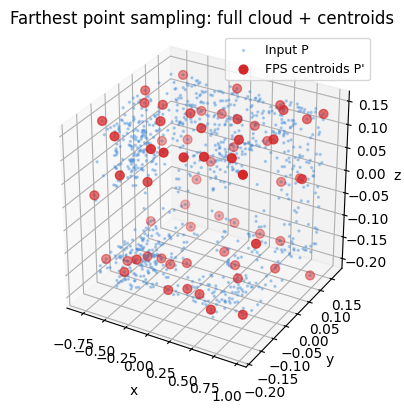

In [4]:
def plot_cloud_and_centroids():
    p = xyz[0].cpu().numpy()
    c = centroid_xyz[0].cpu().numpy()

    fig = plt.figure(figsize=(4, 4))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(p[:, 0], p[:, 1], p[:, 2], s=2, c="#4a90d9", alpha=0.35, label="Input P")
    ax.scatter(c[:, 0], c[:, 1], c[:, 2], s=40, c="#d62728", marker="o", label="FPS centroids P'")
    ax.set_title("Farthest point sampling: full cloud + centroids")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.legend(loc="upper right", fontsize=9)
    try:
        ax.set_box_aspect((1, 1, 1))
    except Exception:
        pass
    plt.tight_layout()
    plt.show()


plot_cloud_and_centroids()

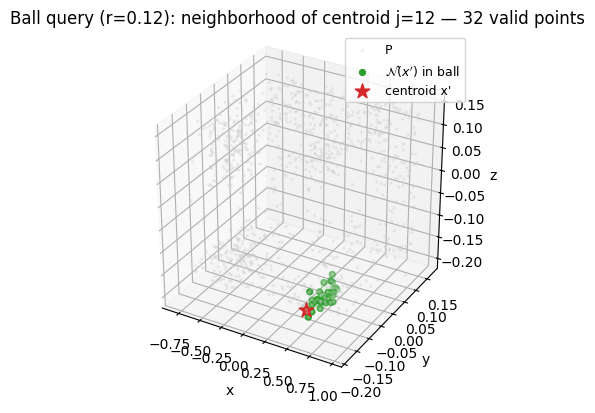

In [5]:
def plot_one_centroid_neighborhood(centroid_index: int = 12):
    """Highlight ball-query neighbors for one centroid (green)."""
    p = xyz[0].cpu().numpy()
    centers = centroid_xyz[0].cpu().numpy()
    j = centroid_index % n_centroids

    idx_j = nbr_idx[0, j].cpu().numpy()
    mask_j = nbr_mask[0, j].cpu().numpy()
    valid = idx_j[mask_j]
    neigh = p[valid]
    center = centers[j]

    fig = plt.figure(figsize=(4, 4))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(p[:, 0], p[:, 1], p[:, 2], s=2, c="#cccccc", alpha=0.25, label="P")
    ax.scatter(neigh[:, 0], neigh[:, 1], neigh[:, 2], s=18, c="#2ca02c", label=r"$\mathcal{N}(x')$ in ball")
    ax.scatter([center[0]], [center[1]], [center[2]], s=120, c="#d62728", marker="*", label="centroid x'")

    for q in neigh:
        ax.plot(
            [center[0], q[0]],
            [center[1], q[1]],
            [center[2], q[2]],
            c="#98df8a",
            alpha=0.35,
            linewidth=0.6,
        )

    ax.set_title(
        f"Ball query (r={radius}): neighborhood of centroid j={j} — {len(neigh)} valid points"
    )
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.legend(loc="upper right", fontsize=9)
    try:
        ax.set_box_aspect((1, 1, 1))
    except Exception:
        pass
    plt.tight_layout()
    plt.show()


plot_one_centroid_neighborhood(12)

In [6]:
# Relative offsets for the chosen centroid: should match (neighbor - centroid) for valid slots
j = 12 % n_centroids
rel_j = rel[0, j].cpu().numpy()
mask_j = nbr_mask[0, j].cpu().numpy()
idx_j = nbr_idx[0, j].cpu().numpy()
p = xyz[0].cpu().numpy()
c0 = centroid_xyz[0, j].cpu().numpy()

for t in range(max_neighbors):
    if not mask_j[t]:
        continue
    i = int(idx_j[t])
    expected = p[i] - c0
    err = np.linalg.norm(rel_j[t, :3] - expected)
    assert err < 1e-4, err
print("Relative coordinates check passed for valid slots (j=%d)." % j)

Relative coordinates check passed for valid slots (j=12).
